In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [57]:
plt.rcParams["figure.figsize"]=(8,5)
plt.style.use("bmh")
RESULTS_DIR="../results"

In [71]:
files = {
    "Adam": "adam_mnist_metrics.csv",
    "SGD": "sgd_mnist_metrics.csv",
    "CALR": "calr_mnist_metrics.csv",
    "CNAG": "cnag_mnist_metrics.csv",
    "RMSProp":"rmsprop_mnist_metrics.csv"
}

data = {}

for name, file in files.items():
    path = os.path.join(RESULTS_DIR, file)
    if os.path.exists(path):
        data[name] = pd.read_csv(path)
    else:
        print(f"Missing: {file}")

print("Loaded optimizers:", list(data.keys()))

Loaded optimizers: ['Adam', 'SGD', 'CALR', 'CNAG', 'RMSProp']


In [72]:
for name, df in data.items():
    print(f"\n{name}")
    display(df.head())


Adam


,epoch,loss,accuracy,grad_norm
0,1,0.248072,92.721667,0.857595
1,2,0.145985,95.835000,0.690328
2,3,0.118774,96.738333,0.627063
3,4,0.119730,96.831667,0.652791
4,5,0.102565,97.293333,0.604598



SGD


,epoch,loss,accuracy,grad_norm
0,1,0.845036,76.826667,1.059041
1,2,0.312553,90.958333,1.196892
2,3,0.248675,92.883333,1.120318
3,4,0.204651,94.123333,1.076102
4,5,0.171111,95.088333,1.037248



CALR


,epoch,loss,accuracy,grad_norm
0,1,0.279408,91.503333,0.840179
1,2,0.114352,96.556667,0.566166
2,3,0.095779,97.135000,0.514482
3,4,0.089317,97.325000,0.514895
4,5,0.083212,97.516667,0.507627



CNAG


,epoch,loss,accuracy,grad_norm
0,1,0.252627,93.343333,0.827208
1,2,0.107534,96.968333,0.599349
2,3,0.090949,97.493333,0.534295
3,4,0.082429,97.731667,0.514487
4,5,0.078313,97.825000,0.531559



RMSProp


,epoch,loss,accuracy,grad_norm
0,1,0.524532,89.431667,1.270740
1,2,0.193786,94.691667,0.684146
2,3,0.169330,95.361667,0.687521
3,4,0.151020,95.943333,0.690817
4,5,0.137174,96.378333,0.683596


In [75]:
colors = {
    "Adam": "#EDA635",
    "SGD": "#066A92", 
    "RMSProp":  "#B4C408",
    "CALR": "#21CC3B", 
    "CNAG": "#F41B46"   
}

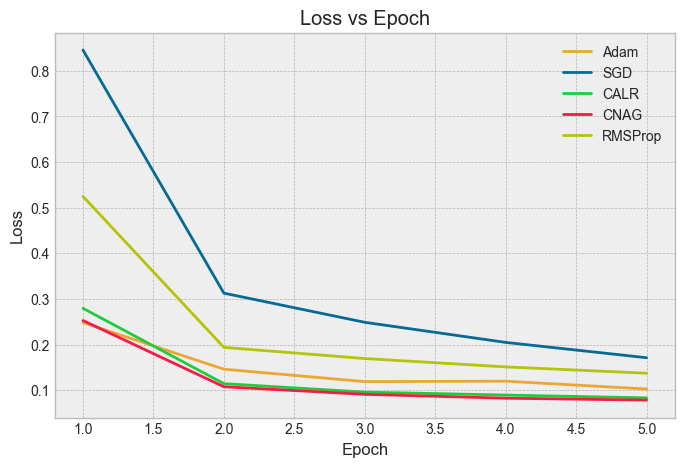

In [76]:
plt.figure()

for name, df in data.items():
    plt.plot(df["epoch"], df["loss"], label=name,color=colors.get(name, "black"))

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid(visible=True, which='both', axis='both')
plt.show()

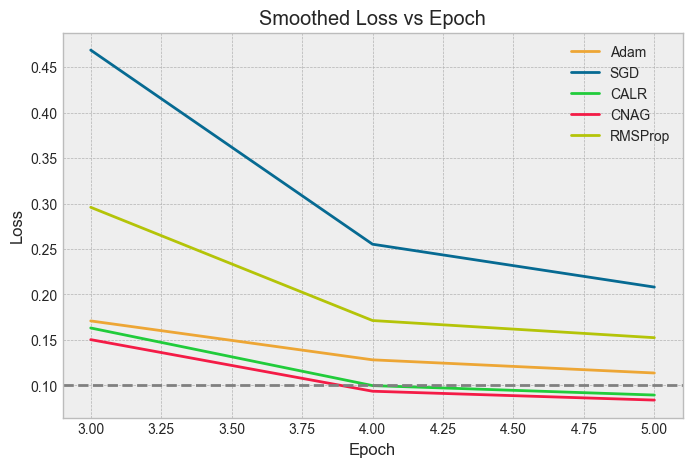

In [77]:
plt.figure()

for name, df in data.items():
    smooth_loss = df["loss"].rolling(window=3).mean()
    plt.plot(df["epoch"], smooth_loss, label=name,color=colors.get(name,"black"))
plt.axhline(y=0.1, linestyle='--', color='gray')
plt.title("Smoothed Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(visible=True,which="both",axis="both")

plt.show()

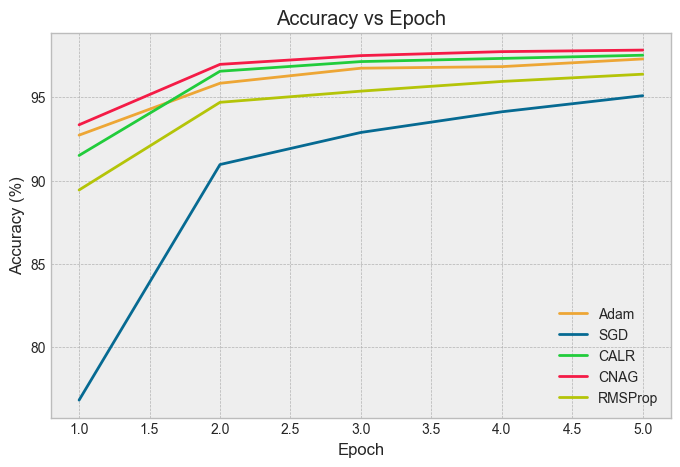

In [78]:
plt.figure()

for name, df in data.items():
    plt.plot(df["epoch"], df["accuracy"], label=name,color=colors.get(name,"black"))

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(visible=True, which='both', axis='both')
plt.show()

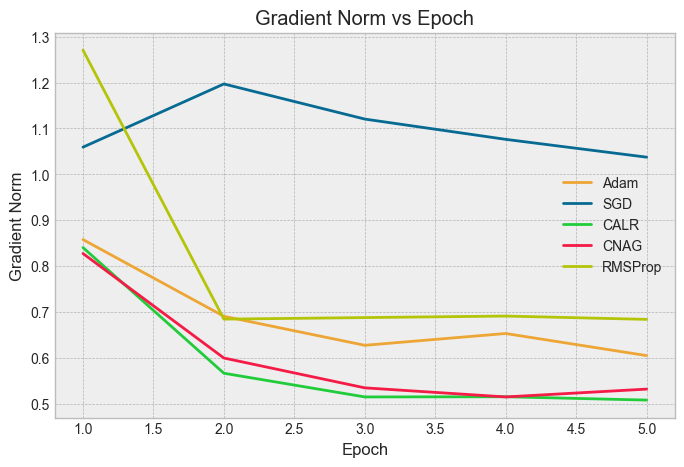

In [79]:
plt.figure()

for name, df in data.items():
    if "grad_norm" in df.columns:
        plt.plot(df["epoch"], df["grad_norm"], label=name,color=colors.get(name,"black"))

plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title("Gradient Norm vs Epoch")
plt.legend()
plt.grid(visible=True,which="both",axis="both")

plt.show()

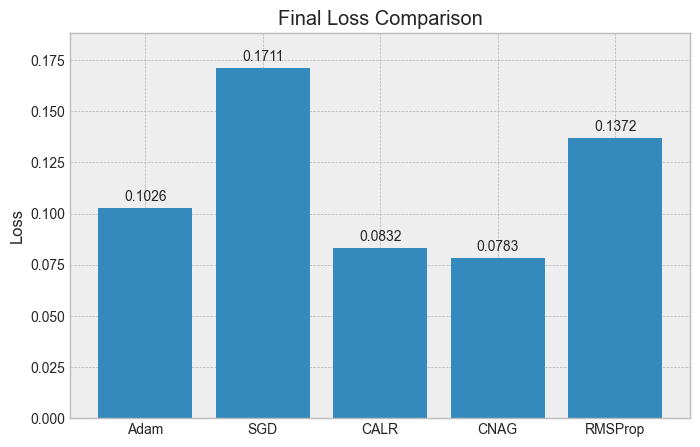

In [80]:

final_losses = {name: df["loss"].iloc[-1] for name, df in data.items()}
fig, ax = plt.subplots()
bars = ax.bar(final_losses.keys(), final_losses.values())
ax.bar_label(bars, padding=3, fmt='%.4f')
ax.set_ylim(0, max(final_losses.values()) * 1.1)

plt.title("Final Loss Comparison")
ax.set_ylabel("Loss")

plt.show()

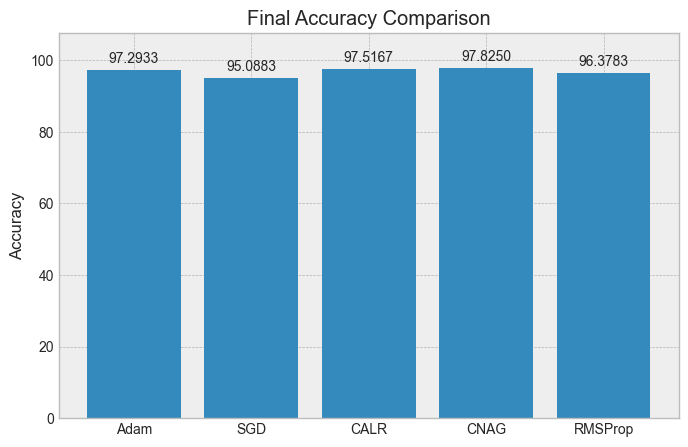

In [81]:
final_acc = {name: df["accuracy"].iloc[-1] for name, df in data.items()}
fig, ax = plt.subplots()
bars = ax.bar(final_acc.keys(), final_acc.values())
ax.bar_label(bars, padding=3, fmt='%.4f')
ax.set_ylim(0, max(final_acc.values()) * 1.1)

plt.title("Final Accuracy Comparison")
ax.set_ylabel("Accuracy")
plt.show()


In [82]:
rows = []

for name, df in data.items():
    final_loss = df["loss"].iloc[-1]
    final_acc = df["accuracy"].iloc[-1]

    rows.append({
        "Optimizer": name,
        "Final Loss": round(final_loss, 4),
        "Final Accuracy (%)": round(final_acc, 2)
    })

performance_df = pd.DataFrame(rows)
performance_df

,Optimizer,Final Loss,Final Accuracy (%)
0,Adam,0.1026,97.29
1,SGD,0.1711,95.09
2,CALR,0.0832,97.52
3,CNAG,0.0783,97.82
4,RMSProp,0.1372,96.38


In [83]:
threshold = 0.2
rows = []

for name, df in data.items():
    conv_epoch = None

    for i, loss in enumerate(df["loss"]):
        if loss < threshold:
            conv_epoch = i + 1
            break

    rows.append({
        "Optimizer": name,
        "Convergence Epoch": conv_epoch if conv_epoch else "Not reached"
    })

conv_df = pd.DataFrame(rows)
conv_df

,Optimizer,Convergence Epoch
0,Adam,2
1,SGD,5
2,CALR,2
3,CNAG,2
4,RMSProp,2


In [84]:
final_table = pd.merge(performance_df, conv_df, on="Optimizer")
final_table

,Optimizer,Final Loss,Final Accuracy (%),Convergence Epoch
0,Adam,0.1026,97.29,2
1,SGD,0.1711,95.09,5
2,CALR,0.0832,97.52,2
3,CNAG,0.0783,97.82,2
4,RMSProp,0.1372,96.38,2
